In [1]:
import pandas as pd

In [2]:
pd.set_option("display.max_columns",None)

In [3]:
df = pd.read_excel("Data.xlsx")

In [4]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [5]:
df.shape

(1200, 14)

In [6]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')

In [7]:
df.dtypes

OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [9]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [10]:
(df.isnull().sum()/len(df))*100

OrderID             0.00
Date                0.00
CustomerID          0.00
Product             0.00
Quantity            0.00
UnitPrice           0.00
ShippingAddress     0.00
PaymentMethod       0.00
OrderStatus         0.00
TrackingNumber      0.00
ItemsInCart         0.00
CouponCode         25.75
ReferralSource      0.00
TotalPrice          0.00
dtype: float64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['OrderID'].duplicated().sum()

np.int64(0)

In [13]:
df['CustomerID'].duplicated().sum()

np.int64(11)

In [14]:
df=df.drop_duplicates(subset='OrderID',keep='first')

In [15]:
for col in df.select_dtypes(include=['string']).columns:
    df[col]=df[col].str.strip()


In [16]:
df['Date']=pd.to_datetime(df['Date'],errors='coerce')

Standardize Text Format


In [17]:
text_columns=[
    'Product',
    'PaymentMethod',
    'OrderStatus',
    'ReferralSource'
]
for col in text_columns:
    df[col]=df[col].str.title()

In [18]:
df['CouponCode']=df['CouponCode'].fillna('No Coupon')

In [19]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


unique value analysis

In [20]:
for col in df.columns:
    print("\nColumn:", col)
    print("Unique Values:", df[col].nunique())
    


Column: OrderID
Unique Values: 1200

Column: Date
Unique Values: 671

Column: CustomerID
Unique Values: 1189

Column: Product
Unique Values: 7

Column: Quantity
Unique Values: 5

Column: UnitPrice
Unique Values: 1193

Column: ShippingAddress
Unique Values: 655

Column: PaymentMethod
Unique Values: 5

Column: OrderStatus
Unique Values: 5

Column: TrackingNumber
Unique Values: 1200

Column: ItemsInCart
Unique Values: 10

Column: CouponCode
Unique Values: 4

Column: ReferralSource
Unique Values: 5

Column: TotalPrice
Unique Values: 1195


In [21]:
for col in df.select_dtypes(include="object").columns:
    print("\nColumn:", col)
    print(df[col].unique())


Column: OrderID
<StringArray>
['ORD200000', 'ORD200001', 'ORD200002', 'ORD200003', 'ORD200004', 'ORD200005',
 'ORD200006', 'ORD200007', 'ORD200008', 'ORD200009',
 ...
 'ORD201190', 'ORD201191', 'ORD201192', 'ORD201193', 'ORD201194', 'ORD201195',
 'ORD201196', 'ORD201197', 'ORD201198', 'ORD201199']
Length: 1200, dtype: str

Column: CustomerID
<StringArray>
['C72649', 'C75739', 'C81728', 'C33540', 'C81840', 'C37249', 'C83492',
 'C41460', 'C26817', 'C31946',
 ...
 'C46886', 'C44148', 'C72007', 'C45104', 'C29885', 'C21126', 'C20095',
 'C79674', 'C64753', 'C57502']
Length: 1189, dtype: str

Column: Product
<StringArray>
['Monitor', 'Phone', 'Tablet', 'Chair', 'Printer', 'Laptop', 'Desk']
Length: 7, dtype: str

Column: ShippingAddress
<StringArray>
['928 Main St', '823 Main St', '512 Main St', '275 Main St', '668 Main St',
 '934 Main St', '986 Main St', '706 Main St', '904 Main St', '102 Main St',
 ...
 '105 Main St', '374 Main St', '777 Main St', '676 Main St', '924 Main St',
 '149 Main St

C:\Users\kalee\AppData\Local\Temp\ipykernel_15144\756451499.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [22]:
df['CalculatedPrice']=df['Quantity']*df['UnitPrice']
df['PriceMatch']=round(df['CalculatedPrice'],2)==round(df['TotalPrice'],2)


In [23]:
print(df['CalculatedPrice'])
print(df['PriceMatch'])
print(df['PriceMatch'].value_counts())

0       2853.10
1        302.70
2       2753.40
3        273.19
4       2504.04
         ...   
1195     107.04
1196    1325.06
1197     873.68
1198    1050.08
1199    2242.32
Name: CalculatedPrice, Length: 1200, dtype: float64
0       True
1       True
2       True
3       True
4       True
        ... 
1195    True
1196    True
1197    True
1198    True
1199    True
Name: PriceMatch, Length: 1200, dtype: bool
PriceMatch
True    1200
Name: count, dtype: int64


 ## most_sale product


In [25]:
print(product_sales)

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64


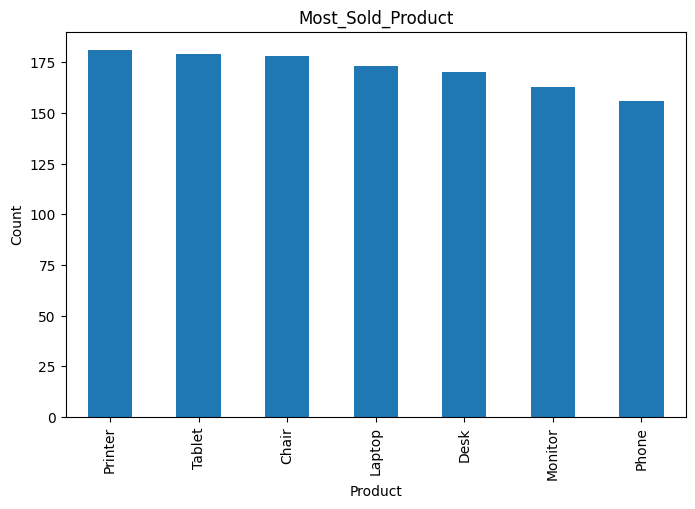

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
product_sales.plot(kind='bar')
plt.title('Most_Sold_Product')
plt.xlabel('Product')
plt.ylabel('Count')
plt.show()

## Revenue Analysis

In [29]:
revenue=df.groupby('Product')['TotalPrice'].sum()
print(revenue)

Product
Chair      195620.11
Desk       167459.93
Laptop     192126.56
Monitor    175651.41
Phone      151722.39
Printer    195612.61
Tablet     186568.95
Name: TotalPrice, dtype: float64


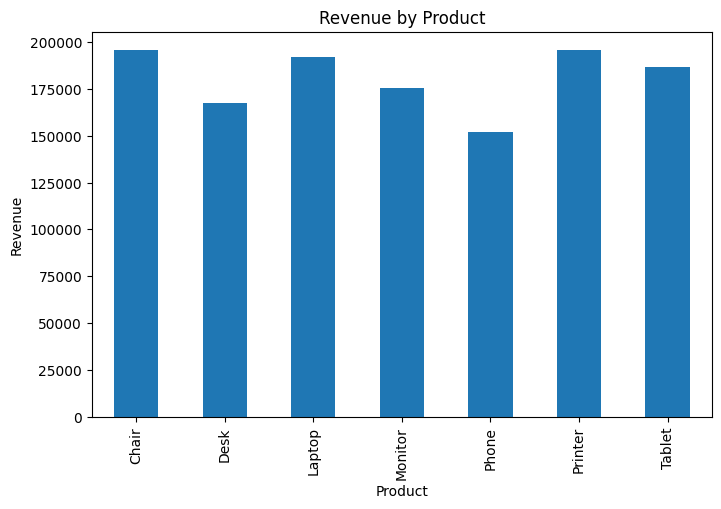

In [30]:
plt.figure(figsize=(8,5))
revenue.plot(kind='bar')

plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue')

plt.show()

## Payment method Analysis

In [33]:
payment_method=df['PaymentMethod'].value_counts()

In [34]:
print(payment_method)

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


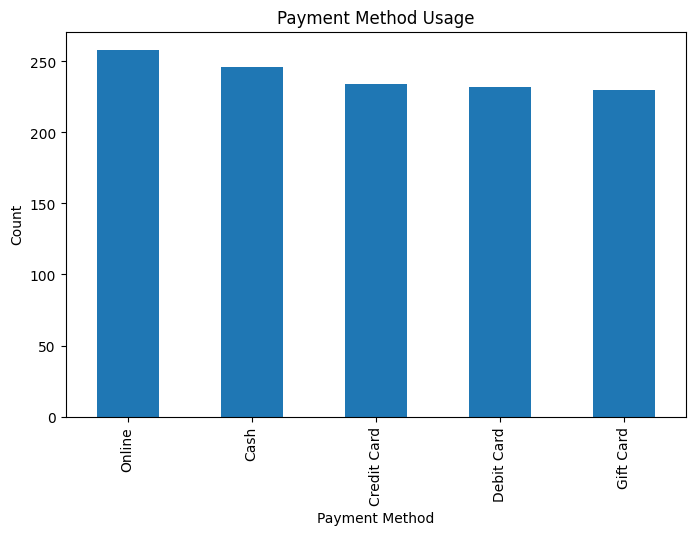

In [35]:
plt.figure(figsize=(8,5))
payment_method.plot(kind='bar')
plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

## Order Status Analysis

In [37]:
Order_Status=df['OrderStatus'].value_counts()
print(Order_Status)

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


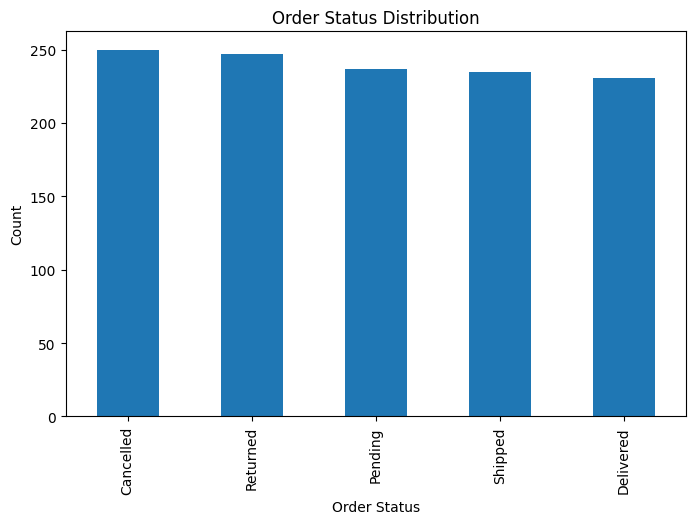

In [38]:
plt.figure(figsize=(8,5))
Order_Status.plot(kind='bar')
plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.show()

In [39]:
referral = df['ReferralSource'].value_counts()
print(referral)

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


In [40]:
print("Most Sold Product :",product_sales.idxmax())

Most Sold Product : Printer


In [41]:
print("Most Used Payment Method :",payment_method.idxmax())

Most Used Payment Method : Online


In [42]:
print("Most Common Order Status :",Order_Status.idxmax())

Most Common Order Status : Cancelled


In [43]:
print("Highest Revenue Product :",revenue.idxmax())

Highest Revenue Product : Chair


In [44]:
df.to_excel('Cleaned_data.xlsx')

In [45]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CalculatedPrice,PriceMatch
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2853.10,True
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,302.70,True
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2753.40,True
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19,True
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2504.04,True
